In [1]:
import copy
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BTC_PATH  = "BTC.json"
TSLA_PATH = "TSLA.json"

SEQ_LEN    = 7          # was 14
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
BATCH_SIZE = 32

EPOCHS             = 300
LR                 = 3e-3
WEIGHT_DECAY       = 1e-4
EARLY_STOP_PATIENCE = 50   # was 20

HOLD_FRAC = 0.30

# Asymmetric loss
W_LOSS           = 1.5    # was 2.0
W_MISS           = 1.0    # was 1.0
ASYM_RETURN_SCALE = 2.0  # was 100.0

CE_WEIGHT    = 0.4    # was 0.2
LABEL_SMOOTH = 0.05

ASSET_EMBED_DIM = 8    # was 4
HIDDEN_DIM      = 32   # was 32
DROPOUT         = 0.50 # was 0.50

LABEL_MAP    = {"BUY": 0, "HOLD": 1, "SELL": 2}
IDX2LABEL    = {0: "BUY", 1: "HOLD", 2: "SELL"}
MOMENTUM_ENC = {"bullish": 1.0, "neutral": 0.0, "bearish": -1.0}
ASSET2ID     = {"BTC": 0, "TSLA": 1}
ID2ASSET     = {0: "BTC", 1: "TSLA"}

FINBERT_MODEL = "ProsusAI/finbert"
MAX_TOKENS    = 512
CHUNK_STRIDE  = 256

print("Device:", DEVICE)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("SEQ_LEN:", SEQ_LEN, "| EPOCHS:", EPOCHS)

Device: cuda
torch: 2.11.0+cu130
cuda available: True
SEQ_LEN: 7 | EPOCHS: 300


In [2]:
with open(BTC_PATH, "r", encoding="utf-8") as f:
    btc_raw = json.load(f)

with open(TSLA_PATH, "r", encoding="utf-8") as f:
    tsla_raw = json.load(f)

def _join_text(x):
    if x is None:
        return ""
    if isinstance(x, list):
        return " ".join(str(v) for v in x)
    return str(x)

def raw_to_df(records):
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if "10k" not in df.columns:
        df["10k"] = [[] for _ in range(len(df))]
    if "10q" not in df.columns:
        df["10q"] = [[] for _ in range(len(df))]

    news_txt = df["news"].apply(_join_text)
    k_txt    = df["10k"].apply(_join_text)
    q_txt    = df["10q"].apply(_join_text)

    df["news_text"] = (news_txt + " " + k_txt + " " + q_txt).str.strip()
    df = df[df["future_price_diff"].notna()].reset_index(drop=True)
    return df

df_btc  = raw_to_df(btc_raw)
df_tsla = raw_to_df(tsla_raw)

print("BTC rows:",  len(df_btc),  "|", df_btc.date.min().date(),  "->", df_btc.date.max().date())
print("TSLA rows:", len(df_tsla), "|", df_tsla.date.min().date(), "->", df_tsla.date.max().date())
display(df_btc[["date","asset","prices","momentum","future_price_diff"]].head(3))

BTC rows: 237 | 2025-08-01 -> 2026-03-25
TSLA rows: 237 | 2025-08-01 -> 2026-03-25


,date,asset,prices,momentum,future_price_diff
0,2025-08-01,BTC,113343.12,bearish,-558.16
1,2025-08-02,BTC,112784.96,bearish,1341.66
2,2025-08-03,BTC,114126.62,bearish,1049.57


In [3]:
def assign_labels_no_leakage(df, hold_frac=HOLD_FRAC, train_frac=TRAIN_FRAC):
    out   = df.copy()
    cut   = int(len(out) * train_frac)
    train_std = out.loc[:cut-1, "future_price_diff"].std()
    thresh    = hold_frac * float(train_std)

    def _label(d):
        if d >  thresh: return LABEL_MAP["BUY"]
        if d < -thresh: return LABEL_MAP["SELL"]
        return LABEL_MAP["HOLD"]

    out["label"]        = out["future_price_diff"].apply(_label)
    out["future_return"] = out["future_price_diff"] / (out["prices"] + 1e-8)
    return out, thresh

df_btc,  btc_thresh  = assign_labels_no_leakage(df_btc)
df_tsla, tsla_thresh = assign_labels_no_leakage(df_tsla)

print(f"BTC  threshold (train-only): {btc_thresh:.4f}")
print(f"TSLA threshold (train-only): {tsla_thresh:.4f}")

print("\nBTC label distribution:")
print(df_btc["label"].value_counts(normalize=True).sort_index().rename(index=IDX2LABEL))

print("\nTSLA label distribution:")
print(df_tsla["label"].value_counts(normalize=True).sort_index().rename(index=IDX2LABEL))

BTC  threshold (train-only): 684.8201
TSLA threshold (train-only): 2.9209

BTC label distribution:
label
BUY     0.320675
HOLD    0.320675
SELL    0.358650
Name: proportion, dtype: float64

TSLA label distribution:
label
BUY     0.274262
HOLD    0.459916
SELL    0.265823
Name: proportion, dtype: float64


In [4]:
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
finbert_model     = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL).to(DEVICE)
finbert_model.eval()

CLS_ID = finbert_tokenizer.cls_token_id
SEP_ID = finbert_tokenizer.sep_token_id

def get_sentiment_vector(text):
    if text is None or str(text).strip() == "":
        return np.array([1/3, 1/3, 1/3], dtype=np.float32)

    token_ids = finbert_tokenizer(
        str(text),
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False
    )["input_ids"]

    chunk_size = MAX_TOKENS - 2
    chunks = []
    if len(token_ids) <= chunk_size:
        chunks = [token_ids]
    else:
        for s in range(0, len(token_ids), CHUNK_STRIDE):
            c = token_ids[s:s + chunk_size]
            if len(c) == 0:
                continue
            chunks.append(c)
            if s + chunk_size >= len(token_ids):
                break

    probs_all = []
    with torch.no_grad():
        for c in chunks:
            input_ids = [CLS_ID] + c + [SEP_ID]
            attn      = [1] * len(input_ids)
            input_ids_t = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)
            attn_t      = torch.tensor([attn],      dtype=torch.long, device=DEVICE)
            logits = finbert_model(input_ids=input_ids_t, attention_mask=attn_t).logits
            p = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            probs_all.append(p)

    mean_probs = np.mean(probs_all, axis=0)
    id2label   = finbert_model.config.id2label
    d = {str(id2label[i]).lower(): mean_probs[i] for i in range(3)}
    return np.array([d.get("negative",1/3), d.get("neutral",1/3), d.get("positive",1/3)],
                    dtype=np.float32)

def extract_sentiments(df, cache_path, desc):
    cache_path = Path(cache_path)
    if cache_path.exists():
        return np.load(cache_path).astype(np.float32)
    out = [get_sentiment_vector(txt) for txt in tqdm(df["news_text"].tolist(), desc=desc)]
    out = np.stack(out).astype(np.float32)
    np.save(cache_path, out)
    return out

btc_sent  = extract_sentiments(df_btc,  "btc_sent.npy",  "FinBERT BTC")
tsla_sent = extract_sentiments(df_tsla, "tsla_sent.npy", "FinBERT TSLA")

print("BTC  sentiment shape:", btc_sent.shape)
print("TSLA sentiment shape:", tsla_sent.shape)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BTC  sentiment shape: (237, 3)
TSLA sentiment shape: (237, 3)


In [5]:
def compute_simple_market_features(df):
    out    = df.copy().sort_values("date").reset_index(drop=True)
    prices = out["prices"].values.astype(np.float64)
    n      = len(prices)

    # 1-day return
    ret1 = np.zeros(n, dtype=np.float32)
    for i in range(1, n):
        ret1[i] = (prices[i] - prices[i-1]) / (prices[i-1] + 1e-8)

    # 5-day volatility
    vol5 = np.zeros(n, dtype=np.float32)
    for i in range(n):
        s = max(0, i - 4)
        vol5[i] = float(np.std(ret1[s:i+1]))

    # z-scored return over 14-day rolling window — scale-invariant across assets
    zscore_ret = np.zeros(n, dtype=np.float32)
    for i in range(n):
        s   = max(0, i - 13)
        seg = ret1[s:i+1]
        mu  = np.mean(seg)
        sd  = np.std(seg) + 1e-8
        zscore_ret[i] = (ret1[i] - mu) / sd

    out["return_1d"]       = ret1
    out["volatility5"]     = vol5
    out["zscore_ret"]      = zscore_ret
    out["momentum_signal"] = out["momentum"].map(MOMENTUM_ENC).fillna(0.0).astype(np.float32)
    return out

df_btc  = compute_simple_market_features(df_btc)
df_tsla = compute_simple_market_features(df_tsla)

FEATURES = [
    "sent_neg", "sent_neu", "sent_pos",
    "return_1d", "volatility5", "momentum_signal",
    "zscore_ret"    # new
]
FEATURE_DIM = len(FEATURES)
print("FEATURE_DIM:", FEATURE_DIM)

FEATURE_DIM: 7


In [6]:
def build_feature_matrix(df, sentiments):
    market = df[["return_1d", "volatility5", "momentum_signal", "zscore_ret"]].values.astype(np.float32)
    return np.concatenate([sentiments, market], axis=1)

def build_sequences(features, labels, future_returns, dates, seq_len=SEQ_LEN):
    X, y, r, end_idx, d = [], [], [], [], []
    for i in range(len(features) - seq_len + 1):
        e = i + seq_len - 1
        X.append(features[i:i+seq_len])
        y.append(labels[e])
        r.append(future_returns[e])
        end_idx.append(e)
        d.append(dates[e])
    return (
        np.stack(X).astype(np.float32),
        np.array(y,       dtype=np.int64),
        np.array(r,       dtype=np.float32),
        np.array(end_idx, dtype=np.int64),
        np.array(d)
    )

def split_by_end_index(n_rows, end_idx, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC):
    train_end = int(n_rows * train_frac)
    val_end   = int(n_rows * (train_frac + val_frac))
    tr = end_idx < train_end
    va = (end_idx >= train_end) & (end_idx < val_end)
    te = end_idx >= val_end
    return tr, va, te

def prepare_asset(df, sentiments, asset_id):
    feat = build_feature_matrix(df, sentiments)
    X, y, r, end_idx, d = build_sequences(
        feat, df["label"].values,
        df["future_return"].values.astype(np.float32),
        df["date"].values, seq_len=SEQ_LEN
    )
    tr, va, te = split_by_end_index(len(df), end_idx)
    out = {
        "X_train": X[tr], "y_train": y[tr], "r_train": r[tr], "date_train": d[tr], "asset_train": np.full(tr.sum(), asset_id, dtype=np.int64),
        "X_val":   X[va], "y_val":   y[va], "r_val":   r[va], "date_val":   d[va], "asset_val":   np.full(va.sum(), asset_id, dtype=np.int64),
        "X_test":  X[te], "y_test":  y[te], "r_test":  r[te], "date_test":  d[te], "asset_test":  np.full(te.sum(), asset_id, dtype=np.int64),
    }
    return out

btc_data  = prepare_asset(df_btc,  btc_sent,  ASSET2ID["BTC"])
tsla_data = prepare_asset(df_tsla, tsla_sent, ASSET2ID["TSLA"])

def merge_split(split_name):
    X = np.concatenate([btc_data[f"X_{split_name}"], tsla_data[f"X_{split_name}"]], axis=0)
    y = np.concatenate([btc_data[f"y_{split_name}"], tsla_data[f"y_{split_name}"]], axis=0)
    r = np.concatenate([btc_data[f"r_{split_name}"], tsla_data[f"r_{split_name}"]], axis=0)
    a = np.concatenate([btc_data[f"asset_{split_name}"], tsla_data[f"asset_{split_name}"]], axis=0)
    d = np.concatenate([btc_data[f"date_{split_name}"], tsla_data[f"date_{split_name}"]], axis=0)
    order = np.lexsort((a, d.astype("datetime64[ns]").astype(np.int64)))
    return X[order], y[order], r[order], a[order], d[order]

X_tr, y_tr, r_tr, a_tr, d_tr = merge_split("train")
X_va, y_va, r_va, a_va, d_va = merge_split("val")
X_te, y_te, r_te, a_te, d_te = merge_split("test")

# globally normalize returns using train set stats only
r_tr_mean = r_tr.mean()
r_tr_std  = r_tr.std() + 1e-8

r_tr_n = ((r_tr - r_tr_mean) / r_tr_std).astype(np.float32)
r_va_n = ((r_va - r_tr_mean) / r_tr_std).astype(np.float32)
r_te_n = ((r_te - r_tr_mean) / r_tr_std).astype(np.float32)

# r_tr/r_va/r_te = original returns — used ONLY for trading_metrics evaluation
# r_tr_n/r_va_n/r_te_n = normalized — used ONLY inside loss during training

print(f"Return stats — mean: {r_tr_mean:.6f}, std: {r_tr_std:.6f}")
print(f"Normalized return range: [{r_tr_n.min():.3f}, {r_tr_n.max():.3f}]")
print(f"Original  return range:  [{r_tr.min():.3f}, {r_tr.max():.3f}]")
print("Train/Val/Test shapes:")
print("Train:", X_tr.shape, y_tr.shape)
print("Val  :", X_va.shape, y_va.shape)
print("Test :", X_te.shape, y_te.shape)
print("Train class dist:", pd.Series(y_tr).value_counts().sort_index().to_dict())

Return stats — mean: -0.000387, std: 0.024192
Normalized return range: [-5.864, 5.176]
Original  return range:  [-0.142, 0.125]
Train/Val/Test shapes:
Train: (366, 7, 7) (366,)
Val  : (48, 7, 7) (48,)
Test : (48, 7, 7) (48,)
Train class dist: {0: 111, 1: 141, 2: 114}


In [7]:
# Per-asset StandardScaler — fixes BTC/TSLA magnitude mismatch
def scale_splits(X_train, X_val, X_test, assets_train, assets_val, assets_test):
    X_tr_out = np.zeros_like(X_train)
    X_va_out = np.zeros_like(X_val)
    X_te_out = np.zeros_like(X_test)
    scalers  = {}

    for aid in [0, 1]:
        tr_mask = (assets_train == aid)
        va_mask = (assets_val   == aid)
        te_mask = (assets_test  == aid)

        s = X_train.shape[1]
        f = X_train.shape[2]

        sc = StandardScaler()
        X_tr_out[tr_mask] = sc.fit_transform(
            X_train[tr_mask].reshape(-1, f)).reshape(tr_mask.sum(), s, f)
        X_va_out[va_mask] = sc.transform(
            X_val[va_mask].reshape(-1, f)).reshape(va_mask.sum(), s, f)
        X_te_out[te_mask] = sc.transform(
            X_test[te_mask].reshape(-1, f)).reshape(te_mask.sum(), s, f)
        scalers[aid] = sc

    return X_tr_out.astype(np.float32), X_va_out.astype(np.float32), X_te_out.astype(np.float32), scalers

X_tr_s, X_va_s, X_te_s, scalers = scale_splits(X_tr, X_va, X_te, a_tr, a_va, a_te)

class FinSeqDataset(Dataset):
    def __init__(self, X, y, r_raw, r_norm, a):
        self.X      = torch.tensor(X,      dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.r_raw  = torch.tensor(r_raw,  dtype=torch.float32)  # for evaluation
        self.r_norm = torch.tensor(r_norm, dtype=torch.float32)  # for loss
        self.a      = torch.tensor(a,      dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.r_raw[i], self.r_norm[i], self.a[i]

train_ds = FinSeqDataset(X_tr_s, y_tr, r_tr, r_tr_n, a_tr)
val_ds   = FinSeqDataset(X_va_s, y_va, r_va, r_va_n, a_va)
test_ds  = FinSeqDataset(X_te_s, y_te, r_te, r_te_n, a_te)

# Replace sampler-based DataLoader with plain shuffle:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   drop_last=False)

print("Batches:", len(train_dl), len(val_dl), len(test_dl))
print("Train class dist:", pd.Series(y_tr).value_counts().sort_index().to_dict())

Batches: 12 2 2
Train class dist: {0: 111, 1: 141, 2: 114}


In [8]:
class UnifiedGRU(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, asset_vocab_size=2,
                 asset_embed_dim=ASSET_EMBED_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.asset_emb = nn.Embedding(asset_vocab_size, asset_embed_dim)

        self.gru = nn.GRU(
            input_size=feature_dim + asset_embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.attn = nn.Linear(hidden_dim, 1)

        # improved head with LayerNorm
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 32),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(32, 3)
        )

    def forward(self, x, asset_id):
        b, s, _ = x.shape
        ae  = self.asset_emb(asset_id).unsqueeze(1).expand(-1, s, -1)
        z   = torch.cat([x, ae], dim=-1)
        h, _ = self.gru(z)
        w   = torch.softmax(self.attn(h), dim=1)
        ctx = (h * w).sum(dim=1)
        return self.head(ctx)


def asymmetric_trading_loss(logits, returns, w_loss=W_LOSS, w_miss=W_MISS, scale=ASYM_RETURN_SCALE):
    probs = torch.softmax(logits, dim=-1)
    abs_r = torch.abs(returns) * scale

    cost_buy  = torch.where(returns < 0,  w_loss * abs_r, torch.zeros_like(abs_r))
    cost_hold = torch.where(returns > 0,  w_miss * abs_r, torch.zeros_like(abs_r))
    cost_sell = torch.where(returns > 0,  w_loss * abs_r, torch.zeros_like(abs_r))

    costs            = torch.stack([cost_buy, cost_hold, cost_sell], dim=1)
    expected_penalty = (probs * costs).sum(dim=1)
    return expected_penalty.mean()


def make_class_weights(y):
    cnt = np.bincount(y, minlength=3).astype(np.float64)
    cnt = np.maximum(cnt, 1.0)
    w   = cnt.sum() / (3.0 * cnt)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

class_w = make_class_weights(y_tr)
print("Class weights:", class_w.detach().cpu().numpy().round(3))

Class weights: [1.099 0.865 1.07 ]


In [9]:
def run_epoch(model, dl, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = total_asym = total_ce = 0.0
    total_n = 0
    preds_all, trues_all = [], []

    for xb, yb, rb_raw, rb_norm, ab in dl:   # unpack 5 values now
        xb     = xb.to(DEVICE)
        yb     = yb.to(DEVICE)
        rb_norm = rb_norm.to(DEVICE)          # only this goes into loss
        ab     = ab.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(xb, ab)
            asym   = asymmetric_trading_loss(logits, rb_norm)  # normalized returns
            ce     = F.cross_entropy(
                logits, yb,
                weight=class_w,
                label_smoothing=LABEL_SMOOTH
            )
            loss = asym + CE_WEIGHT * ce

            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        n = yb.size(0)
        total_n    += n
        total_loss += loss.item() * n
        total_asym += asym.item() * n
        total_ce   += ce.item()   * n

        preds_all.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        trues_all.extend(yb.detach().cpu().numpy().tolist())

    acc = accuracy_score(trues_all, preds_all) if total_n > 0 else 0.0
    f1m = f1_score(trues_all, preds_all, average="macro", zero_division=0) if total_n > 0 else 0.0

    return {
        "loss": total_loss / max(total_n, 1),
        "asym": total_asym / max(total_n, 1),
        "ce":   total_ce   / max(total_n, 1),
        "acc":  acc, "f1m": f1m
    }


model = UnifiedGRU(
    feature_dim=FEATURE_DIM,
    asset_vocab_size=2,
    asset_embed_dim=ASSET_EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {
    "tr_loss": [], "tr_asym": [], "tr_ce": [], "tr_acc": [], "tr_f1m": [],
    "va_loss": [], "va_asym": [], "va_ce": [], "va_acc": [], "va_f1m": []
}

best_val   = 0.0            # was float("inf") — now tracking F1 (higher = better)
best_state = None
wait       = 0

for ep in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_dl, optimizer=optimizer)
    va = run_epoch(model, val_dl,   optimizer=None)
    scheduler.step()

    for k in ["loss", "asym", "ce", "acc", "f1m"]:
        history[f"tr_{k}"].append(tr[k])
        history[f"va_{k}"].append(va[k])

    # early stopping on val macro-F1 instead of val loss
    if va["f1m"] > best_val + 1e-7:
        best_val   = va["f1m"]
        best_state = copy.deepcopy(model.state_dict())
        wait       = 0
    else:
        wait += 1

    if ep == 1 or ep % 10 == 0:
        print(
            f"Epoch {ep:3d}/{EPOCHS} | "
            f"Train L {tr['loss']:.4f} (A {tr['asym']:.4f}, CE {tr['ce']:.4f}) Acc {tr['acc']:.3f} F1 {tr['f1m']:.3f} | "
            f"Val L {va['loss']:.4f} (A {va['asym']:.4f}, CE {va['ce']:.4f}) Acc {va['acc']:.3f} F1 {va['f1m']:.3f}"
        )

    if wait >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {ep}, best val F1={best_val:.5f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("Loaded best validation checkpoint.")

Epoch   1/300 | Train L 1.3668 (A 0.9151, CE 1.1292) Acc 0.331 F1 0.327 | Val L 1.1533 (A 0.7160, CE 1.0932) Acc 0.458 F1 0.251
Epoch  10/300 | Train L 1.2981 (A 0.8295, CE 1.1716) Acc 0.361 F1 0.206 | Val L 1.1597 (A 0.7019, CE 1.1446) Acc 0.438 F1 0.203
Epoch  20/300 | Train L 1.2595 (A 0.7832, CE 1.1909) Acc 0.366 F1 0.251 | Val L 1.1840 (A 0.7005, CE 1.2088) Acc 0.354 F1 0.206
Epoch  30/300 | Train L 1.2477 (A 0.7859, CE 1.1546) Acc 0.385 F1 0.228 | Val L 1.1929 (A 0.7062, CE 1.2166) Acc 0.396 F1 0.189
Epoch  40/300 | Train L 1.1493 (A 0.6893, CE 1.1500) Acc 0.423 F1 0.388 | Val L 1.3100 (A 0.7588, CE 1.3780) Acc 0.354 F1 0.341
Epoch  50/300 | Train L 1.0612 (A 0.6085, CE 1.1318) Acc 0.426 F1 0.406 | Val L 1.4002 (A 0.7469, CE 1.6332) Acc 0.208 F1 0.151
Epoch  60/300 | Train L 0.8803 (A 0.4769, CE 1.0084) Acc 0.508 F1 0.506 | Val L 1.5762 (A 0.8005, CE 1.9394) Acc 0.271 F1 0.262
Epoch  70/300 | Train L 0.7314 (A 0.3389, CE 0.9813) Acc 0.571 F1 0.574 | Val L 1.6496 (A 0.7850, CE 2.1

In [10]:
def collect_outputs(model, dl):
    model.eval()
    probs_all, preds_all, trues_all, rets_raw_all, assets_all = [], [], [], [], []

    with torch.no_grad():
        for xb, yb, rb_raw, rb_norm, ab in dl:   # unpack 5 values
            xb, ab  = xb.to(DEVICE), ab.to(DEVICE)
            logits  = model(xb, ab)
            probs   = torch.softmax(logits, dim=-1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)

            probs_all.append(probs)
            preds_all.append(preds)
            trues_all.append(yb.cpu().numpy())
            rets_raw_all.append(rb_raw.cpu().numpy())   # raw returns for metrics
            assets_all.append(ab.cpu().numpy())

    return (
        np.vstack(probs_all),
        np.concatenate(preds_all),
        np.concatenate(trues_all),
        np.concatenate(rets_raw_all),   # raw, not normalized
        np.concatenate(assets_all),
    )


def trading_metrics(preds, fwd_returns):
    pos   = np.where(preds == LABEL_MAP["BUY"], 1.0,
            np.where(preds == LABEL_MAP["SELL"], -1.0, 0.0))
    daily = pos * fwd_returns
    eq    = np.cumprod(1.0 + daily)

    cr  = float(eq[-1] - 1.0) if len(eq) else 0.0
    dv  = float(np.std(daily) + 1e-12)
    sr  = float((np.mean(daily) / dv) * np.sqrt(252)) if dv > 0 else 0.0
    peak = np.maximum.accumulate(eq) if len(eq) else np.array([1.0])
    md  = float(((eq - peak) / (peak + 1e-12)).min()) if len(eq) else 0.0
    av  = float(dv * np.sqrt(252))
    bh  = np.cumprod(1.0 + fwd_returns)
    bh_cr = float(bh[-1] - 1.0) if len(bh) else 0.0

    return {"CR": cr, "SR": sr, "MD": md, "DV": dv, "AV": av,
            "BH_CR": bh_cr, "daily": daily, "equity": eq, "bh_equity": bh}


def probs_to_actions_per_asset(probs, assets, th_map):
    out   = np.full(len(probs), LABEL_MAP["HOLD"], dtype=np.int64)
    score = probs[:, 0] - probs[:, 2]

    for aid in [0, 1]:
        m = (assets == aid)
        if m.sum() == 0:
            continue
        buy_th  = th_map[aid]["buy_th"]
        sell_th = th_map[aid]["sell_th"]
        s = score[m]
        a = np.full(m.sum(), LABEL_MAP["HOLD"], dtype=np.int64)
        a[s >=  buy_th]  = LABEL_MAP["BUY"]
        a[s <= -sell_th] = LABEL_MAP["SELL"]
        out[m] = a

    return out

In [11]:
def objective_from_metrics(tm):
    return tm["CR"] + 0.2 * tm["SR"] - 0.3 * abs(tm["MD"])

def hold_rate(preds):
    return float(np.mean(preds == LABEL_MAP["HOLD"]))

def tune_thresholds_per_asset(probs_va, rets_va, assets_va,
                              buy_grid=np.linspace(0.01, 0.35, 35),
                              sell_grid=np.linspace(0.01, 0.35, 35),
                              min_hold=0.15, max_hold=0.70):
    best_map    = {}
    diagnostics = {}

    for aid in [0, 1]:
        m = (assets_va == aid)
        p = probs_va[m]
        r = rets_va[m]

        best = None
        for bt in buy_grid:
            for st in sell_grid:
                th_map_tmp = {aid: {"buy_th": float(bt), "sell_th": float(st)}}
                preds = probs_to_actions_per_asset(p, np.full(len(p), aid), th_map_tmp)

                hr = hold_rate(preds)
                if not (min_hold <= hr <= max_hold):
                    continue

                tm  = trading_metrics(preds, r)
                obj = objective_from_metrics(tm)

                cand = {"buy_th": float(bt), "sell_th": float(st),
                        "hold_rate": hr, "tm": tm, "obj": obj}
                if best is None or cand["obj"] > best["obj"]:
                    best = cand

        if best is None:
            best = {"buy_th": 0.08, "sell_th": 0.08,
                    "hold_rate": None, "tm": None, "obj": -1e9}

        best_map[aid]    = {"buy_th": best["buy_th"], "sell_th": best["sell_th"]}
        diagnostics[aid] = best

    return best_map, diagnostics


probs_va, preds_va_argmax, trues_va, rets_va, assets_va = collect_outputs(model, val_dl)

th_map, th_diag = tune_thresholds_per_asset(probs_va, rets_va, assets_va)
print("Per-asset thresholds:", th_map)
print("Diagnostics:")
for aid in [0, 1]:
    print(ID2ASSET[aid], th_diag[aid])

Per-asset thresholds: {0: {'buy_th': 0.08, 'sell_th': 0.08}, 1: {'buy_th': 0.19999999999999998, 'sell_th': 0.30999999999999994}}
Diagnostics:
BTC {'buy_th': 0.08, 'sell_th': 0.08, 'hold_rate': None, 'tm': None, 'obj': -1000000000.0}
TSLA {'buy_th': 0.19999999999999998, 'sell_th': 0.30999999999999994, 'hold_rate': 0.2916666666666667, 'tm': {'CR': -0.010024631019589725, 'SR': -0.47233871999586863, 'MD': -0.04469825474502555, 'DV': 0.011775818004628309, 'AV': 0.18693531554762016, 'BH_CR': -0.018948495388031006, 'daily': array([-0.        ,  0.        ,  0.        , -0.01890632,  0.        ,
        0.02615169,  0.00088713,  0.        ,  0.        ,  0.        ,
       -0.01631372,  0.        ,  0.        ,  0.00026722,  0.        ,
        0.        , -0.02911471,  0.0238852 ,  0.01959057, -0.        ,
       -0.01485628,  0.        ,  0.        ,  0.        ]), 'equity': array([1.        , 1.        , 1.        , 0.98109368, 0.98109368,
       1.00675094, 1.00764406, 1.00764406, 1.007644

TEST Accuracy: 0.5
TEST Macro-F1: 0.4877
              precision    recall  f1-score   support

         BUY       0.41      0.58      0.48        12
        HOLD       1.00      0.28      0.43        18
        SELL       0.46      0.67      0.55        18

    accuracy                           0.50        48
   macro avg       0.62      0.51      0.49        48
weighted avg       0.65      0.50      0.49        48



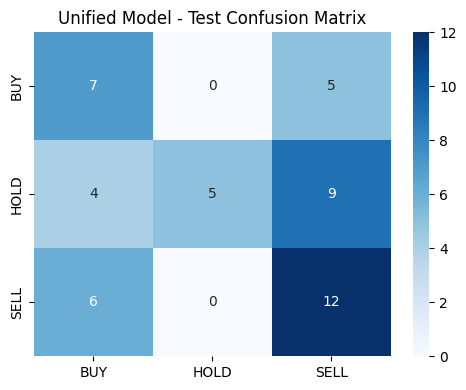

Overall Trading Metrics
CR: +19.91% | SR: 2.840 | MD: -7.81% | DV: 2.2604% | AV: 35.88% | B&H CR: -7.74%

BTC Trading Metrics
CR: +20.10% | SR: 5.100 | MD: -6.39% | DV: 2.4790% | AV: 39.35% | B&H CR: -0.01%

TSLA Trading Metrics
CR: -0.15% | SR: 0.101 | MD: -6.32% | DV: 1.9407% | AV: 30.81% | B&H CR: -7.74%

Hold rate overall: 0.104
Hold rate BTC    : 0.042
Hold rate TSLA   : 0.167


In [12]:
probs_te, preds_te_argmax, trues_te, rets_te, assets_te = collect_outputs(model, test_dl)

preds_te = probs_to_actions_per_asset(probs_te, assets_te, th_map)

print("TEST Accuracy:", round(accuracy_score(trues_te, preds_te), 4))
print("TEST Macro-F1:", round(f1_score(trues_te, preds_te, average="macro", zero_division=0), 4))
print(classification_report(trues_te, preds_te,
                             target_names=["BUY","HOLD","SELL"], zero_division=0))

cm = confusion_matrix(trues_te, preds_te, labels=[0,1,2])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BUY","HOLD","SELL"],
            yticklabels=["BUY","HOLD","SELL"])
plt.title("Unified Model - Test Confusion Matrix")
plt.tight_layout()
plt.show()

overall = trading_metrics(preds_te, rets_te)
print("Overall Trading Metrics")
print(f"CR: {overall['CR']*100:+.2f}% | SR: {overall['SR']:.3f} | MD: {overall['MD']*100:.2f}% | "
      f"DV: {overall['DV']*100:.4f}% | AV: {overall['AV']*100:.2f}% | B&H CR: {overall['BH_CR']*100:+.2f}%")

for aid, name in [(0,"BTC"),(1,"TSLA")]:
    m = (assets_te == aid)
    if m.sum() == 0:
        continue
    tm = trading_metrics(preds_te[m], rets_te[m])
    print(f"\n{name} Trading Metrics")
    print(f"CR: {tm['CR']*100:+.2f}% | SR: {tm['SR']:.3f} | MD: {tm['MD']*100:.2f}% | "
          f"DV: {tm['DV']*100:.4f}% | AV: {tm['AV']*100:.2f}% | B&H CR: {tm['BH_CR']*100:+.2f}%")

print("\nHold rate overall:", round(np.mean(preds_te == LABEL_MAP["HOLD"]), 3))
print("Hold rate BTC    :", round(np.mean(preds_te[assets_te==0] == LABEL_MAP["HOLD"]), 3))
print("Hold rate TSLA   :", round(np.mean(preds_te[assets_te==1] == LABEL_MAP["HOLD"]), 3))

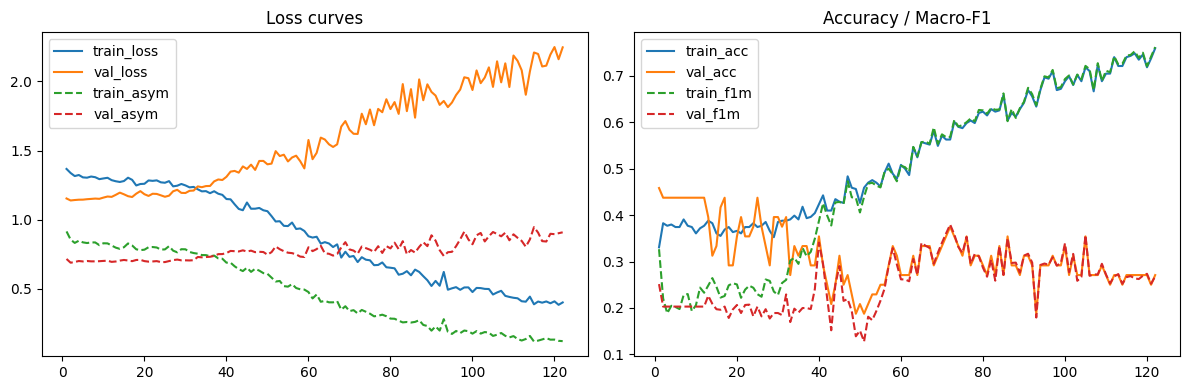

In [13]:
e = range(1, len(history["tr_loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(e, history["tr_loss"], label="train_loss")
ax[0].plot(e, history["va_loss"], label="val_loss")
ax[0].plot(e, history["tr_asym"], "--", label="train_asym")
ax[0].plot(e, history["va_asym"], "--", label="val_asym")
ax[0].set_title("Loss curves")
ax[0].legend()

ax[1].plot(e, history["tr_acc"], label="train_acc")
ax[1].plot(e, history["va_acc"], label="val_acc")
ax[1].plot(e, history["tr_f1m"], "--", label="train_f1m")
ax[1].plot(e, history["va_f1m"], "--", label="val_f1m")
ax[1].set_title("Accuracy / Macro-F1")
ax[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Run this diagnostic cell BEFORE any other changes
print("=== BTC future_return stats ===")
print(df_btc["future_return"].describe())
print("\nRows where |future_return| > 0.20 (>20% daily move):")
print(df_btc[np.abs(df_btc["future_return"]) > 0.20][["date","prices","future_price_diff","future_return"]].head(10))

print("\n=== TSLA future_return stats ===")
print(df_tsla["future_return"].describe())
print("\nRows where |future_return| > 0.20:")
print(df_tsla[np.abs(df_tsla["future_return"]) > 0.20][["date","prices","future_price_diff","future_return"]].head(10))

print("\n=== Return distribution ===")
print("BTC  r_tr range:", r_tr.min(), "to", r_tr.max())
print("TSLA r_tr range:")
btc_mask = (a_tr == 0)
tsla_mask = (a_tr == 1)
print("  BTC  in r_tr:", r_tr[btc_mask].min(), "to", r_tr[btc_mask].max())
print("  TSLA in r_tr:", r_tr[tsla_mask].min(), "to", r_tr[tsla_mask].max())

print("\n=== Normalized return range ===")
print("r_tr_n range:", r_tr_n.min(), "to", r_tr_n.max())

=== BTC future_return stats ===
count    237.000000
mean      -0.001726
std        0.024765
min       -0.142243
25%       -0.015041
50%       -0.000849
75%        0.012301
max        0.124839
Name: future_return, dtype: float64

Rows where |future_return| > 0.20 (>20% daily move):
Empty DataFrame
Columns: [date, prices, future_price_diff, future_return]
Index: []

=== TSLA future_return stats ===
count    237.000000
mean       0.001113
std        0.022026
min       -0.066442
25%       -0.009645
50%        0.000000
75%        0.010176
max        0.073561
Name: future_return, dtype: float64

Rows where |future_return| > 0.20:
Empty DataFrame
Columns: [date, prices, future_price_diff, future_return]
Index: []

=== Return distribution ===
BTC  r_tr range: -0.14224294 to 0.12483855
TSLA r_tr range:
  BTC  in r_tr: -0.14224294 to 0.12483855
  TSLA in r_tr: -0.06644221 to 0.07356092

=== Normalized return range ===
r_tr_n range: -5.863781 to 5.176372


In [15]:
# Predict next-day action for BTC/TSLA using the last available sequence
# (Run after training + threshold tuning cells)

import numpy as np
import torch


def predict_next_action(df, sentiments, aid, asset_name):
    market = df[["return_1d", "volatility5", "momentum_signal", "zscore_ret"]].values.astype(np.float32)
    feat = np.concatenate([sentiments, market], axis=1).astype(np.float32)
    x_last = feat[-SEQ_LEN:]
    x_last_s = scalers[aid].transform(x_last).astype(np.float32)

    xb = torch.tensor(x_last_s[None, ...], dtype=torch.float32, device=DEVICE)
    ab = torch.tensor([aid], dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(xb, ab)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    score = probs[0] - probs[2]
    buy_th = th_map[aid]["buy_th"]
    sell_th = th_map[aid]["sell_th"]

    if score >= buy_th:
        action = "BUY"
    elif score <= -sell_th:
        action = "SELL"
    else:
        action = "HOLD"

    print(f"{asset_name} -> {action}")
    print(f"  Probs [BUY/HOLD/SELL]: {probs[0]:.3f} / {probs[1]:.3f} / {probs[2]:.3f}")
    print(f"  Score: {score:+.3f} | Buy threshold: {buy_th:.3f} | Sell threshold: {sell_th:.3f}")
    print()
    return action, probs


print("=== NEXT-DAY ACTION PREDICTION ===")
print()
btc_action, btc_probs = predict_next_action(df_btc, btc_sent, aid=0, asset_name="BTC")
tsla_action, tsla_probs = predict_next_action(df_tsla, tsla_sent, aid=1, asset_name="TSLA")

=== NEXT-DAY ACTION PREDICTION ===

BTC -> SELL
  Probs [BUY/HOLD/SELL]: 0.010 / 0.382 / 0.608
  Score: -0.599 | Buy threshold: 0.080 | Sell threshold: 0.080

TSLA -> BUY
  Probs [BUY/HOLD/SELL]: 0.996 / 0.004 / 0.000
  Score: +0.996 | Buy threshold: 0.200 | Sell threshold: 0.310



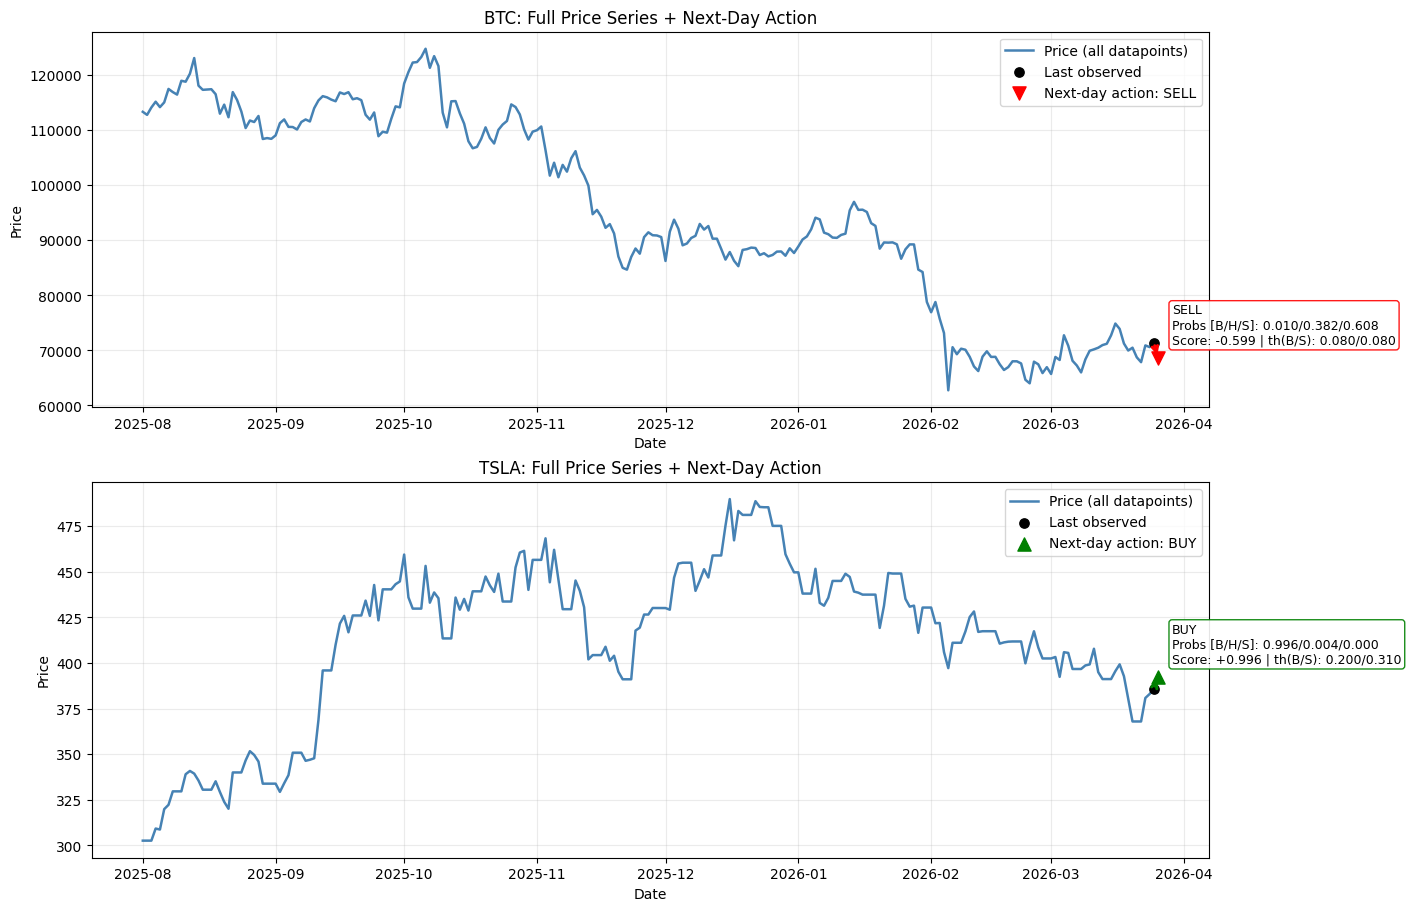

In [16]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Uses trained model, scalers, th_map, SEQ_LEN, DEVICE from previous cells

def infer_next_action(df, sentiments, aid):
    market = df[["return_1d", "volatility5", "momentum_signal", "zscore_ret"]].values.astype(np.float32)
    feat = np.concatenate([sentiments, market], axis=1).astype(np.float32)
    x_last = feat[-SEQ_LEN:]
    x_last_s = scalers[aid].transform(x_last).astype(np.float32)

    xb = torch.tensor(x_last_s[None, ...], dtype=torch.float32, device=DEVICE)
    ab = torch.tensor([aid], dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(xb, ab)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    score = float(probs[0] - probs[2])
    buy_th = float(th_map[aid]["buy_th"])
    sell_th = float(th_map[aid]["sell_th"])

    if score >= buy_th:
        action = "BUY"
    elif score <= -sell_th:
        action = "SELL"
    else:
        action = "HOLD"

    return action, probs, score, buy_th, sell_th


def plot_full_prices_with_next_action(df, sentiments, aid, asset_name, ax):
    action, probs, score, buy_th, sell_th = infer_next_action(df, sentiments, aid)

    dates = pd.to_datetime(df["date"])
    prices = df["prices"].astype(float).values

    ax.plot(dates, prices, color="steelblue", lw=1.8, label="Price (all datapoints)")
    ax.scatter(dates.iloc[-1], prices[-1], color="black", s=45, zorder=5, label="Last observed")

    next_date = dates.iloc[-1] + pd.Timedelta(days=1)

    # Arrow placement only for visualization (NOT price prediction)
    spread = max(float(np.std(prices)) * 0.15, 1e-6)
    if action == "BUY":
        y2 = prices[-1] + spread
        color = "green"
        marker = "^"
    elif action == "SELL":
        y2 = prices[-1] - spread
        color = "red"
        marker = "v"
    else:
        y2 = prices[-1]
        color = "gray"
        marker = "o"

    ax.annotate(
        "",
        xy=(next_date, y2),
        xytext=(dates.iloc[-1], prices[-1]),
        arrowprops=dict(arrowstyle="->", lw=2.2, color=color),
        zorder=6
    )
    ax.scatter(next_date, y2, c=color, s=90, marker=marker, zorder=7, label=f"Next-day action: {action}")

    txt = (
        f"{action}\n"
        f"Probs [B/H/S]: {probs[0]:.3f}/{probs[1]:.3f}/{probs[2]:.3f}\n"
        f"Score: {score:+.3f} | th(B/S): {buy_th:.3f}/{sell_th:.3f}"
    )
    ax.annotate(
        txt, xy=(next_date, y2), xytext=(10, 10), textcoords="offset points",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, alpha=0.9)
    )

    ax.set_title(f"{asset_name}: Full Price Series + Next-Day Action")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")


fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
plot_full_prices_with_next_action(df_btc, btc_sent, 0, "BTC", axes[0])
plot_full_prices_with_next_action(df_tsla, tsla_sent, 1, "TSLA", axes[1])
plt.show()